Завантаження даних


--2025-11-30 18:35:40--  https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.251.143.91, 142.250.130.207, 142.250.120.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.251.143.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1625420029 (1,5G) [application/zip]
Saving to: '101_food_classes_10_percent.zip.1'

     0K .......... .......... .......... .......... ..........  0%  274K 96m38s
    50K .......... .......... .......... .......... ..........  0%  414K 80m15s
   100K .......... .......... .......... .......... ..........  0%  872K 63m37s
   150K .......... .......... .......... .......... ..........  0%  945K 54m42s
   200K .......... .......... .......... .......... ..........  0% 1,32M 47m40s
   250K .......... .......... .......... .......... ..........  0% 2,51M 41m26s
   300K .......... .......... .......... .......... ....


Всього класів: 101
Перші 10 класів: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']

Обрані класи:
i1 = 6: beignets
i2 = 36: falafel
i3 = 66: nachos

Підготовка тренувальних даних
Found 225 images belonging to 3 classes.

Підготовка тестових даних
Found 750 images belonging to 3 classes.

Кількість тренувальних зображень: 225
Кількість тестових зображень: 750

Створення моделі CNN

Початок навчання:


c:\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.3422 - loss: 1.4409 - val_accuracy: 0.5493 - val_loss: 1.0931 - learning_rate: 0.0010
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 980ms/step - accuracy: 0.3689 - loss: 1.1009 - val_accuracy: 0.5467 - val_loss: 1.0295 - learning_rate: 0.0010
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 981ms/step - accuracy: 0.5289 - loss: 1.0351 - val_accuracy: 0.4600 - val_loss: 1.0047 - learning_rate: 0.0010
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 939ms/step - accuracy: 0.4356 - loss: 1.0291 - val_accuracy: 0.4240 - val_loss: 1.0028 - learning_rate: 0.0010
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 944ms/step - accuracy: 0.4444 - loss: 1.0187 - val_accuracy: 0.4373 - val_loss: 0.9880 - learning_rate: 0.0010
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 982ms/step - accuracy: 0.5111 - loss: 0.9833 - val_accuracy: 0.5467 - val_loss: 0.9159 - learning_rate: 0.0010
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 949ms/step - accuracy: 0.5911 - loss: 0.8651 - val_accuracy: 0.

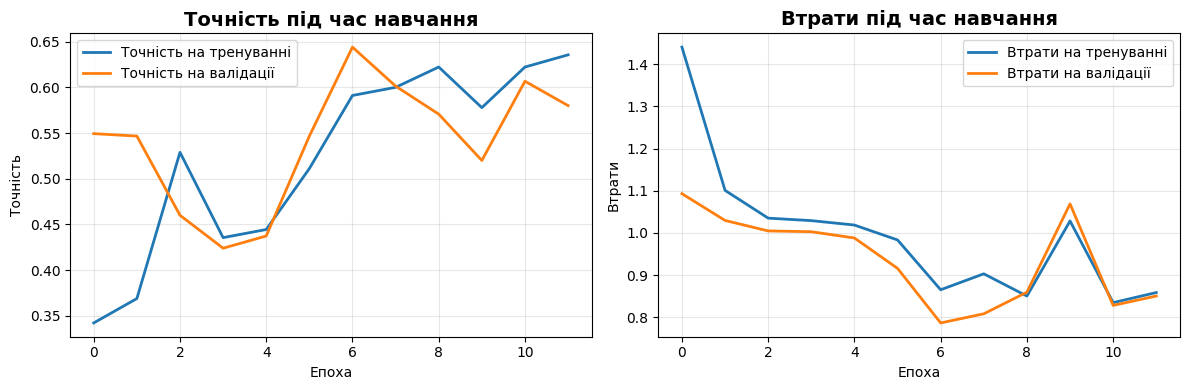


Оцінка моделі на тестових даних:
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.6440 - loss: 0.7864
Фінальна точність на тестових даних: 0.6440
Фінальні втрати на тестових даних: 0.7864

Прогнозування для прикладів:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step


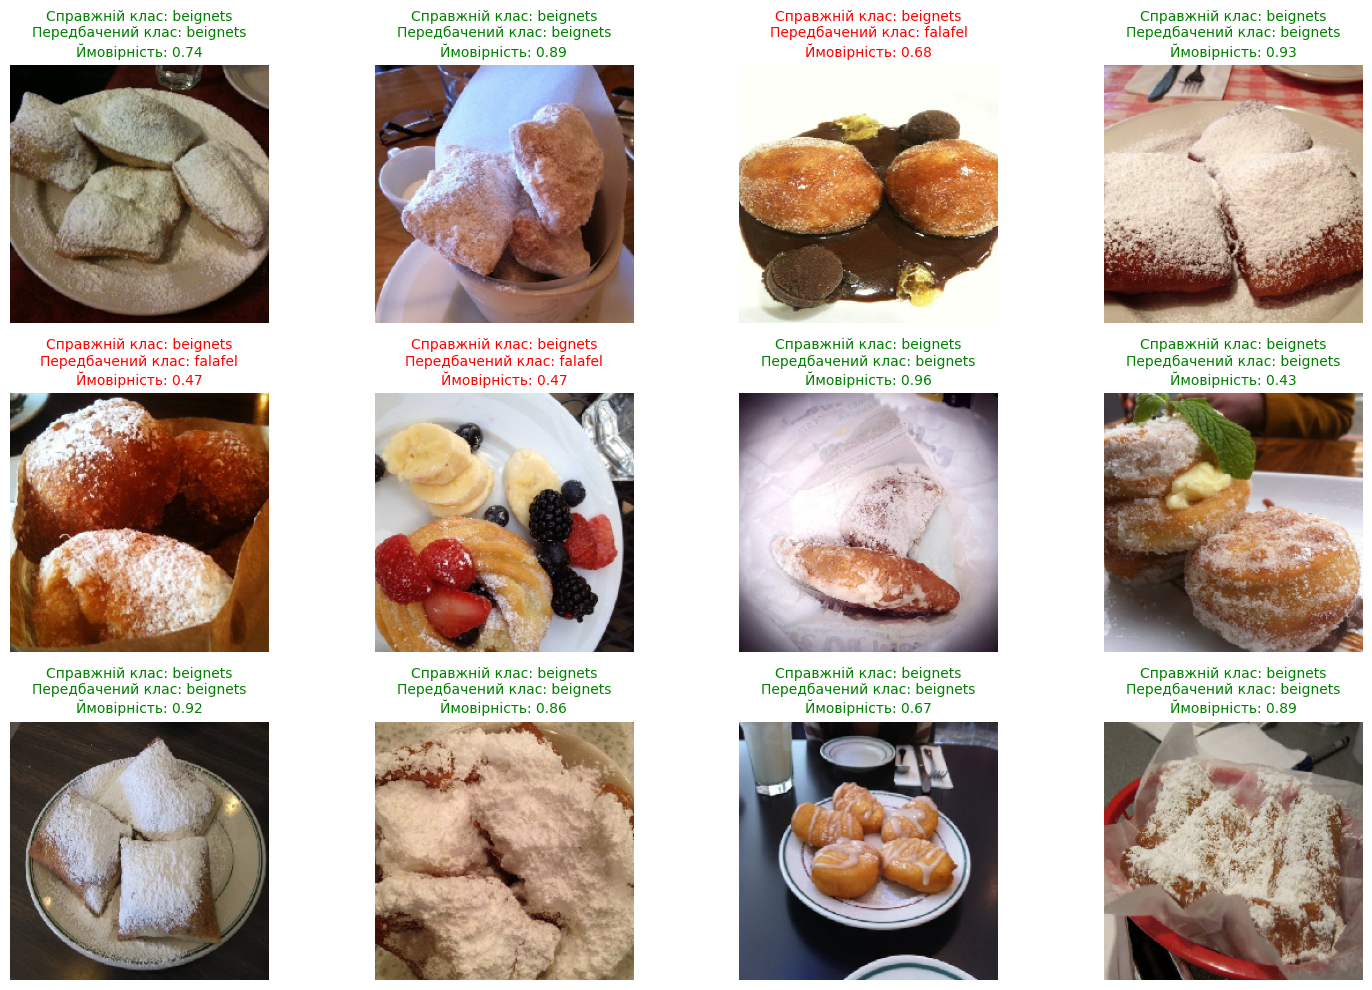


Матриця плутанини:
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 148ms/step


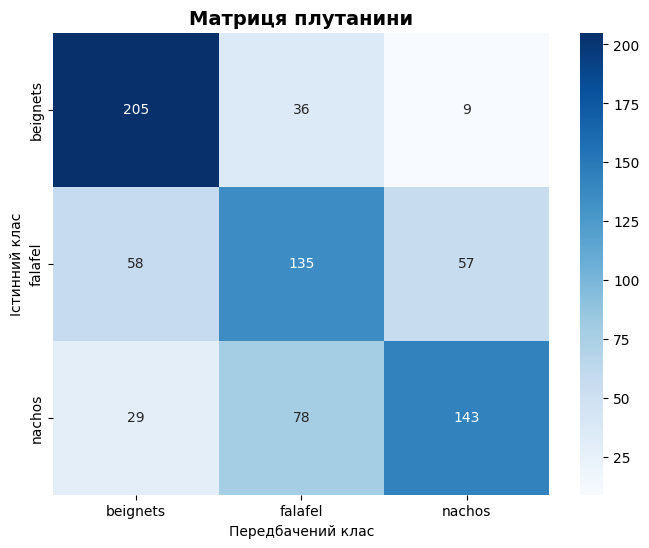


Результати оцінки ефективності моделі по метриках precision, recall, support та F1-score:
              precision    recall  f1-score   support

    beignets       0.70      0.82      0.76       250
     falafel       0.54      0.54      0.54       250
      nachos       0.68      0.57      0.62       250

    accuracy                           0.64       750
   macro avg       0.64      0.64      0.64       750
weighted avg       0.64      0.64      0.64       750


Модель збережено як food_classification_model.keras

Результати роботи:
Номер за списком: 7
Надані індекси: i1=6, i2=36, i3=66
Обрані класи: ['beignets', 'falafel', 'nachos']
Фінальна точність: 0.6440
Кількість епох: 12
Розмір батчу: 32
Розмір зображень: (224, 224)


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os
import zipfile
from tensorflow.keras.preprocessing.image import ImageDataGenerator


print("Завантаження даних")


!wget https://storage.googleapis.com/ztm_tf_course/food_vision/101_food_classes_10_percent.zip


with zipfile.ZipFile("101_food_classes_10_percent.zip", 'r') as zip_ref:
    zip_ref.extractall()


train_dir = "101_food_classes_10_percent/train"
test_dir = "101_food_classes_10_percent/test"


class_names = sorted(os.listdir(train_dir))
print(f"\nВсього класів: {len(class_names)}")
print("Перші 10 класів:", class_names[:10])


n = 7  
i1 = n - 1  
i2 = n + 29  
i3 = n + 59  

selected_classes = [class_names[i1], class_names[i2], class_names[i3]]
print(f"\nОбрані класи:")
print(f"i1 = {i1}: {selected_classes[0]}")
print(f"i2 = {i2}: {selected_classes[1]}")
print(f"i3 = {i3}: {selected_classes[2]}")


IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("\nПідготовка тренувальних даних")
train_datagen = ImageDataGenerator(rescale=1./255)
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=selected_classes,
    seed=42
)

print("\nПідготовка тестових даних")
test_datagen = ImageDataGenerator(rescale=1./255)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=selected_classes,
    seed=42,
    shuffle=False
)

print(f"\nКількість тренувальних зображень: {train_data.samples}")
print(f"Кількість тестових зображень: {test_data.samples}")


print("\nСтворення моделі CNN")


model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),  
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(selected_classes), activation='softmax')
])



model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


print("\nПочаток навчання:")


early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=0.0001
)

history = model.fit(
    train_data,
    epochs=30,
    validation_data=test_data,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)


print("\nВізуалізація результатів:")


plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Точність на тренуванні', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Точність на валідації', linewidth=2)
plt.title('Точність під час навчання', fontsize=14, fontweight='bold')
plt.xlabel('Епоха')
plt.ylabel('Точність')
plt.legend()
plt.grid(True, alpha=0.3)


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Втрати на тренуванні', linewidth=2)
plt.plot(history.history['val_loss'], label='Втрати на валідації', linewidth=2)
plt.title('Втрати під час навчання', fontsize=14, fontweight='bold')
plt.xlabel('Епоха')
plt.ylabel('Втрати')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\nОцінка моделі на тестових даних:")
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Фінальна точність на тестових даних: {test_accuracy:.4f}")
print(f"Фінальні втрати на тестових даних: {test_loss:.4f}")

print("\nПрогнозування для прикладів:")
sample_images, sample_labels = next(iter(test_data))
predictions = model.predict(sample_images)


class_indices = train_data.class_indices
class_names_list = list(class_indices.keys())

plt.figure(figsize=(15, 10))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(sample_images[i])
    
    true_class = class_names_list[np.argmax(sample_labels[i])]
    pred_class = class_names_list[np.argmax(predictions[i])]
    confidence = np.max(predictions[i])
    
    color = 'green' if true_class == pred_class else 'red'
    plt.title(f'Справжній клас: {true_class}\nПередбачений клас: {pred_class}\nЙмовірність: {confidence:.2f}', 
              color=color, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()


from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print("\nМатриця плутанини:")


test_data.reset()
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_data.classes


cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names_list, 
            yticklabels=class_names_list)
plt.title('Матриця плутанини', fontsize=14, fontweight='bold')
plt.xlabel('Передбачений клас')
plt.ylabel('Істинний клас')
plt.show()


print("\nРезультати оцінки ефективності моделі по метриках precision, recall, support та F1-score:")
print(classification_report(y_true, y_pred_classes, target_names=class_names_list))


model.save('food_classification_model.keras')
print("\nМодель збережено як food_classification_model.keras")



print("\nРезультати роботи:")
print(f"Номер за списком: {n}")
print(f"Надані індекси: i1={i1}, i2={i2}, i3={i3}")
print(f"Обрані класи: {selected_classes}")
print(f"Фінальна точність: {test_accuracy:.4f}")
print(f"Кількість епох: {len(history.history['accuracy'])}")
print(f"Розмір батчу: {BATCH_SIZE}")
print(f"Розмір зображень: {IMG_SIZE}")